## LOAD DATA AND EDA


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.impute import SimpleImputer
from factor_analyzer import calculate_kmo, FactorAnalyzer
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv('heloc_dataset_v1.csv')
df

,RiskPerformance,ExternalRiskEstimate,MSinceOldestTradeOpen,MSinceMostRecentTradeOpen,AverageMInFile,NumSatisfactoryTrades,NumTrades60Ever2DerogPubRec,NumTrades90Ever2DerogPubRec,PercentTradesNeverDelq,MSinceMostRecentDelq,...,PercentInstallTrades,MSinceMostRecentInqexcl7days,NumInqLast6M,NumInqLast6Mexcl7days,NetFractionRevolvingBurden,NetFractionInstallBurden,NumRevolvingTradesWBalance,NumInstallTradesWBalance,NumBank2NatlTradesWHighUtilization,PercentTradesWBalance
0,Bad,55,144,4,84,20,3,0,83,2,...,43,0,0,0,33,-8,8,1,1,69
1,Bad,61,58,15,41,2,4,4,100,-7,...,67,0,0,0,0,-8,0,-8,-8,0
2,Bad,67,66,5,24,9,0,0,100,-7,...,44,0,4,4,53,66,4,2,1,86
3,Bad,66,169,1,73,28,1,1,93,76,...,57,0,5,4,72,83,6,4,3,91
4,Bad,81,333,27,132,12,0,0,100,-7,...,25,0,1,1,51,89,3,1,0,80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10454,Good,73,131,5,57,21,0,0,95,80,...,19,7,0,0,26,-8,5,2,0,100
10455,Bad,65,147,39,68,11,0,0,92,28,...,42,1,1,1,86,53,2,2,1,80
10456,Bad,74,129,6,64,18,1,1,100,-7,...,33,3,4,4,6,-8,5,-8,0,56
10457,Bad,72,234,12,113,42,2,2,96,35,...,20,6,0,0,19,-8,4,1,0,38


In [ ]:
df.columns

Index(['RiskPerformance', 'ExternalRiskEstimate', 'MSinceOldestTradeOpen',
       'MSinceMostRecentTradeOpen', 'AverageMInFile', 'NumSatisfactoryTrades',
       'NumTrades60Ever2DerogPubRec', 'NumTrades90Ever2DerogPubRec',
       'PercentTradesNeverDelq', 'MSinceMostRecentDelq',
       'MaxDelq2PublicRecLast12M', 'MaxDelqEver', 'NumTotalTrades',
       'NumTradesOpeninLast12M', 'PercentInstallTrades',
       'MSinceMostRecentInqexcl7days', 'NumInqLast6M', 'NumInqLast6Mexcl7days',
       'NetFractionRevolvingBurden', 'NetFractionInstallBurden',
       'NumRevolvingTradesWBalance', 'NumInstallTradesWBalance',
       'NumBank2NatlTradesWHighUtilization', 'PercentTradesWBalance'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10459 entries, 0 to 10458
Data columns (total 24 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   RiskPerformance                     10459 non-null  object
 1   ExternalRiskEstimate                10459 non-null  int64 
 2   MSinceOldestTradeOpen               10459 non-null  int64 
 3   MSinceMostRecentTradeOpen           10459 non-null  int64 
 4   AverageMInFile                      10459 non-null  int64 
 5   NumSatisfactoryTrades               10459 non-null  int64 
 6   NumTrades60Ever2DerogPubRec         10459 non-null  int64 
 7   NumTrades90Ever2DerogPubRec         10459 non-null  int64 
 8   PercentTradesNeverDelq              10459 non-null  int64 
 9   MSinceMostRecentDelq                10459 non-null  int64 
 10  MaxDelq2PublicRecLast12M            10459 non-null  int64 
 11  MaxDelqEver                         10459 non-null  in

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isna().sum()

,0
RiskPerformance,0
ExternalRiskEstimate,0
MSinceOldestTradeOpen,0
MSinceMostRecentTradeOpen,0
AverageMInFile,0
NumSatisfactoryTrades,0
NumTrades60Ever2DerogPubRec,0
NumTrades90Ever2DerogPubRec,0
PercentTradesNeverDelq,0
MSinceMostRecentDelq,0


## DATA PROCESSING

In [ ]:
# 2. Xác định các cột số (loại trừ cột object như 'RiskPerformance')
numeric_cols = df.select_dtypes(include=[np.number]).columns

# 3. Tìm giá trị âm trong các cột số
negative_values = set()

for col in numeric_cols:
    negatives = df[col][df[col] < 0].unique()
    negative_values.update(negatives)

# 4. In ra danh sách các giá trị âm đặc biệt
print("Các giá trị âm phát hiện được trong dữ liệu:")
negative_values

Các giá trị âm phát hiện được trong dữ liệu:


{np.int64(-9), np.int64(-8), np.int64(-7)}

=> 3 số này thường có ý nghĩa là NAN vì:

* -9 -> unknown
* -8 -> Không thể tính toán / Không xác định
* -7 -> không áp dụng


In [ ]:
# Thay các giá trị âm bằng NaN
df[numeric_cols] = df[numeric_cols].replace(list(negative_values), np.nan)

In [ ]:
df.isna().sum()

,0
RiskPerformance,0
ExternalRiskEstimate,12
MSinceOldestTradeOpen,241
MSinceMostRecentTradeOpen,2
AverageMInFile,2
NumSatisfactoryTrades,2
NumTrades60Ever2DerogPubRec,2
NumTrades90Ever2DerogPubRec,2
PercentTradesNeverDelq,2
MSinceMostRecentDelq,4842


Skewness of MSinceOldestTradeOpen: 0.71 --> Symmetric


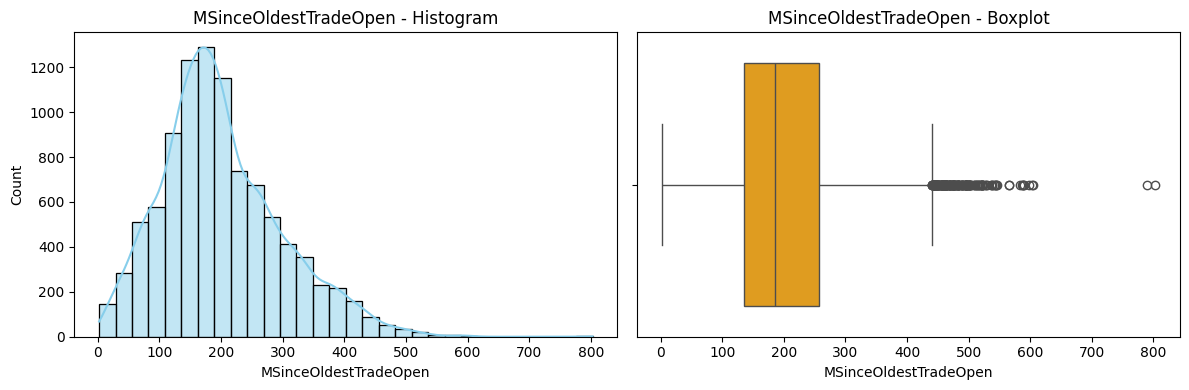

Skewness of MSinceMostRecentDelq: 1.07 --> Right-skewed


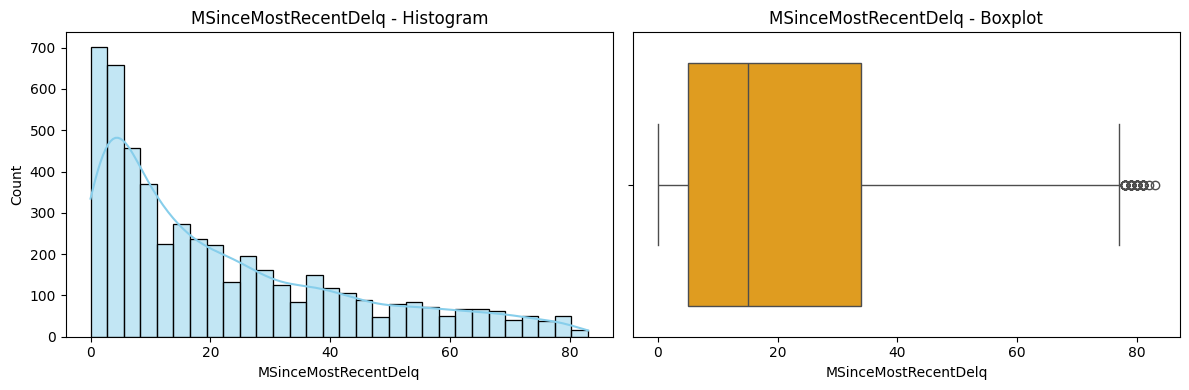

Skewness of MSinceMostRecentInqexcl7days: 2.40 --> Right-skewed


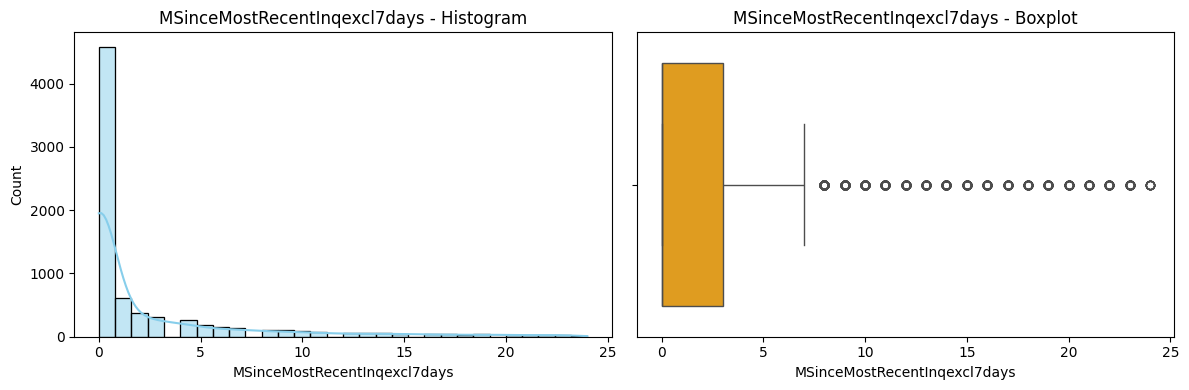

Skewness of NetFractionInstallBurden: 0.02 --> Symmetric


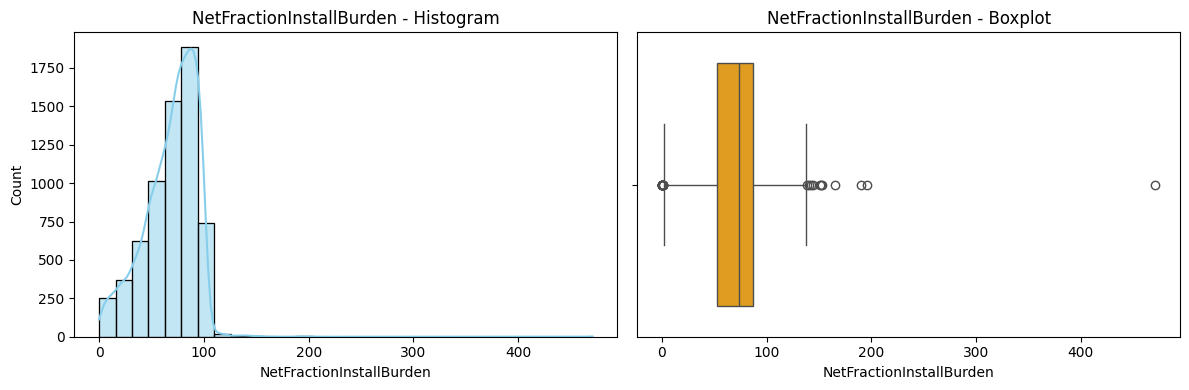

Skewness of NumInstallTradesWBalance: 2.46 --> Right-skewed


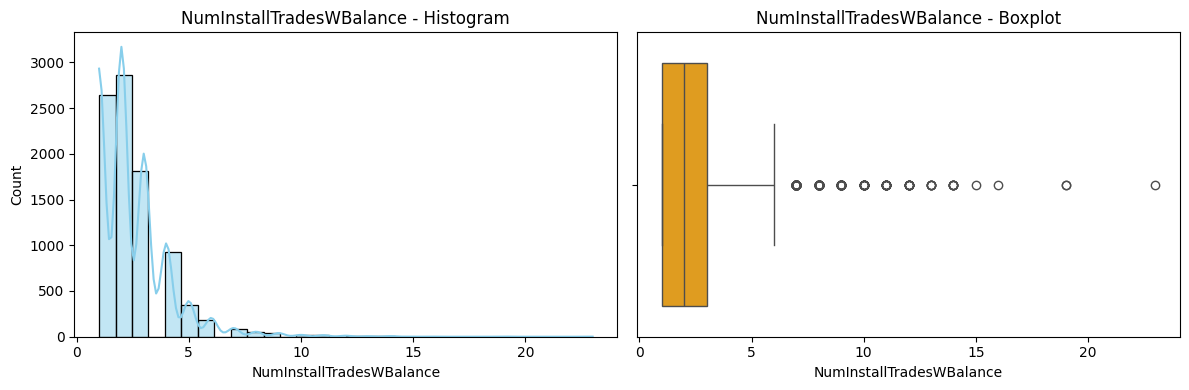

Skewness of NumBank2NatlTradesWHighUtilization: 2.56 --> Right-skewed


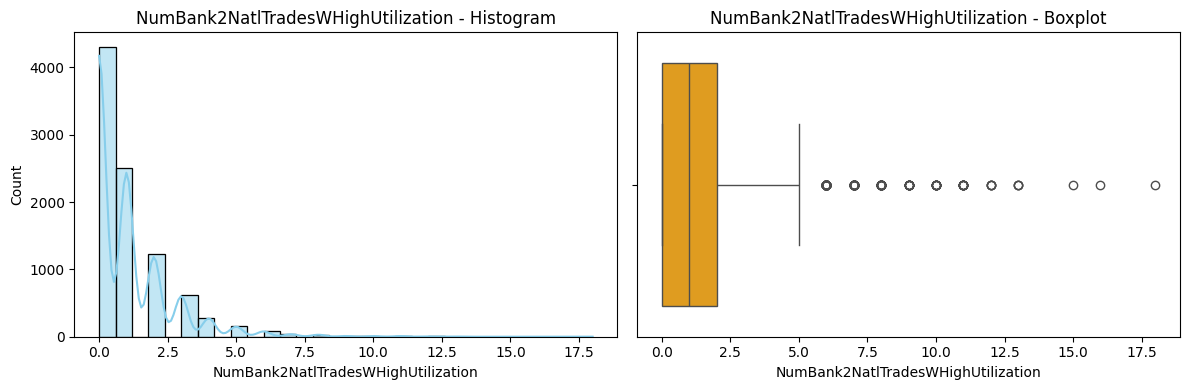

Skewness of NetFractionRevolvingBurden: 0.62 --> Symmetric


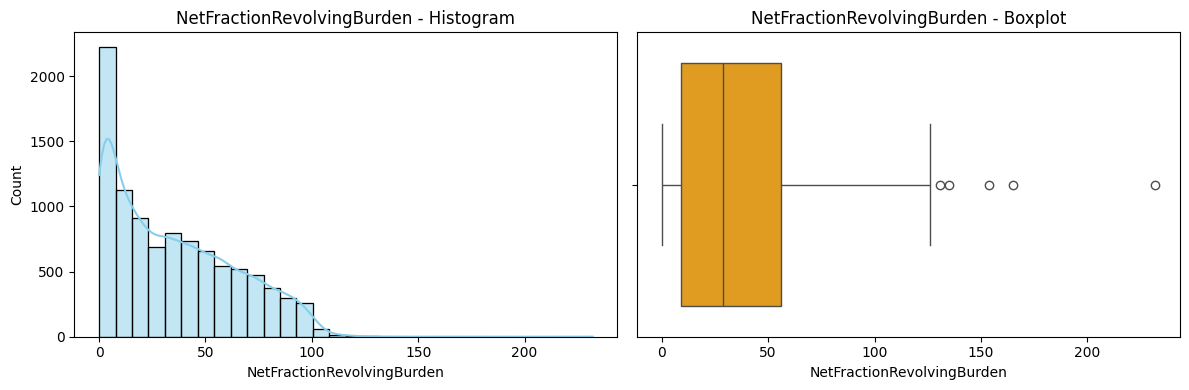

Skewness of NumRevolvingTradesWBalance: 1.69 --> Right-skewed


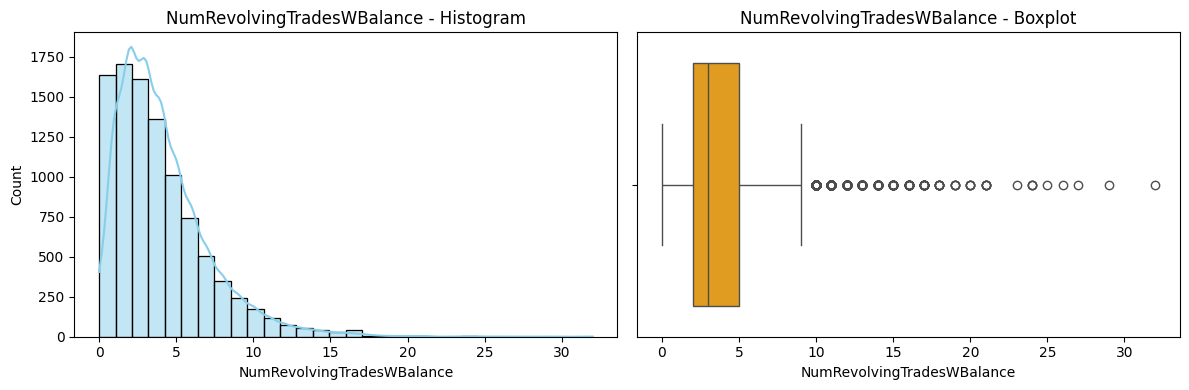

In [ ]:
from scipy.stats import skew
# Danh sách các cột muốn kiểm tra (bạn có thể chỉnh lại)
cols_to_check = [
    'MSinceOldestTradeOpen', 'MSinceMostRecentDelq', 'MSinceMostRecentInqexcl7days',
    'NetFractionInstallBurden', 'NumInstallTradesWBalance',
    'NumBank2NatlTradesWHighUtilization', 'NetFractionRevolvingBurden',
    'NumRevolvingTradesWBalance'
]

# Vòng lặp kiểm tra phân phối
for col in cols_to_check:
    plt.figure(figsize=(12, 4))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df[col].dropna(), kde=True, bins=30, color='skyblue')
    plt.title(f'{col} - Histogram')

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col], color='orange')
    plt.title(f'{col} - Boxplot')

    # Tính skewness
    skew_val = skew(df[col].dropna())
    print(f"Skewness of {col}: {skew_val:.2f} --> {'Right-skewed' if skew_val > 1 else 'Left-skewed' if skew_val < -1 else 'Symmetric'}")

    plt.tight_layout()
    plt.show()

In [ ]:

# 4. Dùng SimpleImputer để điền NaN bằng median (hoặc mean tùy bạn)
imputer = SimpleImputer(strategy='median')
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])
df_clean = df[numeric_cols].copy()
# Check lại còn NaN không
print("Còn thiếu giá trị nào không", df[numeric_cols].isna().sum().sum())

Còn thiếu giá trị nào không 0


In [ ]:
df.isna().sum()

,0
RiskPerformance,0
ExternalRiskEstimate,0
MSinceOldestTradeOpen,0
MSinceMostRecentTradeOpen,0
AverageMInFile,0
NumSatisfactoryTrades,0
NumTrades60Ever2DerogPubRec,0
NumTrades90Ever2DerogPubRec,0
PercentTradesNeverDelq,0
MSinceMostRecentDelq,0


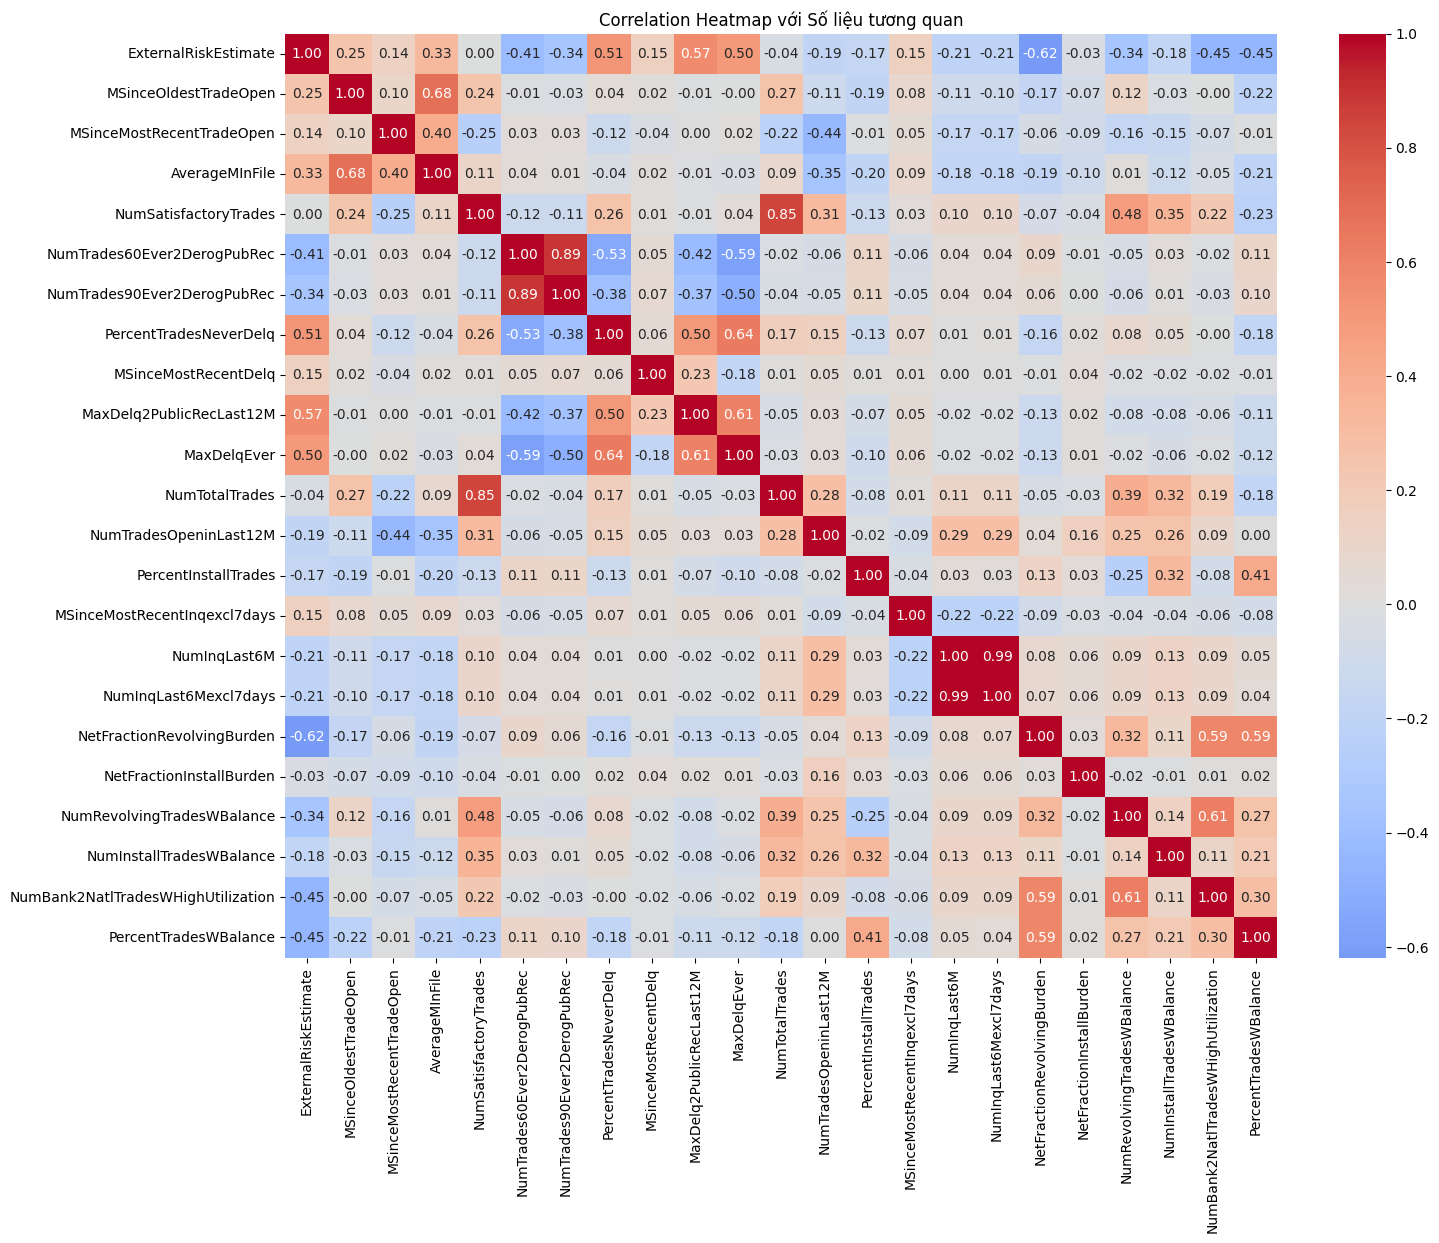

In [ ]:
#vẽ correlation của các biến
plt.figure(figsize=(16, 12))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', annot_kws={"size": 10})
plt.title("Correlation Heatmap với Số liệu tương quan")
plt.show()

 Số lượng outlier theo từng biến:
MSinceMostRecentInqexcl7days          353
MaxDelq2PublicRecLast12M              336
MSinceMostRecentDelq                  296
PercentTradesNeverDelq                236
NumBank2NatlTradesWHighUtilization    190
NumTrades60Ever2DerogPubRec           181
NumTrades90Ever2DerogPubRec           179
NumInqLast6M                          178
NumInqLast6Mexcl7days                 166
MSinceMostRecentTradeOpen             156
NetFractionInstallBurden              155
NumInstallTradesWBalance              144
NumRevolvingTradesWBalance            135
NumTradesOpeninLast12M                118
AverageMInFile                        112
NumTotalTrades                        111
PercentInstallTrades                   92
NumSatisfactoryTrades                  85
MSinceOldestTradeOpen                  62
PercentTradesWBalance                  45
ExternalRiskEstimate                   11
NetFractionRevolvingBurden              7
MaxDelqEver                             0


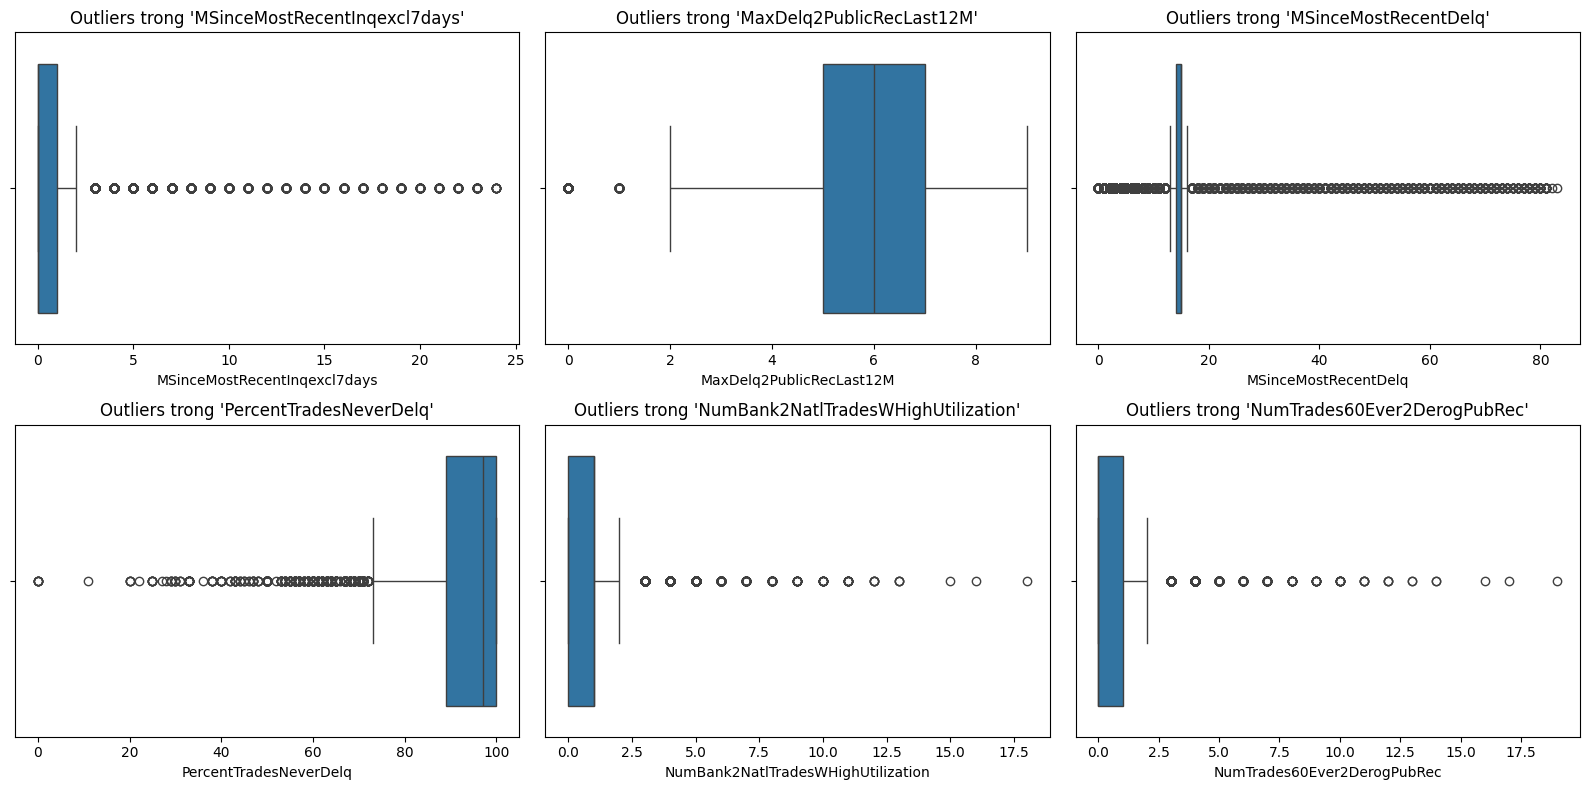

In [ ]:
# Tính z-score
z_scores = np.abs(stats.zscore(df[numeric_cols], nan_policy='omit'))

# Xác định outliers (z > 3)
outliers = (z_scores > 3)

# Đếm số outliers theo cột
outlier_counts = pd.Series(np.sum(outliers, axis=0), index=numeric_cols)
print(" Số lượng outlier theo từng biến:")
print(outlier_counts.sort_values(ascending=False))

# ------------------ BOX PLOT cho một số biến nhiều outlier ------------------ #
top_outlier_cols = outlier_counts.sort_values(ascending=False).head(6).index

plt.figure(figsize=(16, 8))
for i, col in enumerate(top_outlier_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[col])
    plt.title(f"Outliers trong '{col}'")
plt.tight_layout()
plt.show()

In [ ]:
# B1: Dùng IQR trước
Q1 = df_clean[numeric_cols].quantile(0.25)
Q3 = df_clean[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
df_iqr_filtered = df_clean[~((df_clean[numeric_cols] < (Q1 - 1.5 * IQR)) |
                             (df_clean[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

# B2: Sau đó dùng Z-score tiếp trên dữ liệu đã lọc IQR
z_scores = np.abs(stats.zscore(df_iqr_filtered[numeric_cols], nan_policy='omit'))
df_final = df_iqr_filtered[(z_scores < 3).all(axis=1)]


In [ ]:
z_scores_final = np.abs(stats.zscore(df_final[numeric_cols], nan_policy='omit'))
# Có còn dòng nào có ít nhất 1 outlier không?
any_outliers = (z_scores_final > 3).any(axis=1).sum()
print(f"Tổng số dòng vẫn còn outliers: {any_outliers}")



Tổng số dòng vẫn còn outliers: 0


## FEATURE ENGINEERING

### tính woe và xác định iv để feature selection trước khi chia train test

In [ ]:
# Tạo lại biến target nếu chưa có
if 'target' not in df.columns and 'RiskPerformance' in df.columns:
    df['target'] = (df['RiskPerformance'] == 'Bad').astype(int)


In [ ]:
# 1. Tạo biến target từ RiskPerformance nếu chưa có
if 'target' not in df.columns and 'RiskPerformance' in df.columns:
    df['target'] = (df['RiskPerformance'] == 'Bad').astype(int)

# 2. Làm sạch dữ liệu: loại bỏ các biến không dùng & bản ghi thiếu
df_clean = df.copy()
df_clean = df_clean.dropna(subset=['target'])

# 3. Hàm tính WOE & IV
def compute_iv_woe(df, feature, target):
    eps = 0.0001  # tránh chia cho 0
    lst = []
    for val in df[feature].unique():
        val_total = df[df[feature] == val].shape[0]
        val_good = df[(df[feature] == val) & (df[target] == 0)].shape[0]
        val_bad = df[(df[feature] == val) & (df[target] == 1)].shape[0]

        dist_good = val_good / (df[df[target] == 0].shape[0] + eps)
        dist_bad = val_bad / (df[df[target] == 1].shape[0] + eps)

        woe = np.log((dist_good + eps) / (dist_bad + eps))
        iv = (dist_good - dist_bad) * woe

        lst.append({'Value': val, 'WOE': woe, 'IV': iv})

    iv_df = pd.DataFrame(lst)
    woe_map = dict(zip(iv_df['Value'], iv_df['WOE']))
    iv_total = iv_df['IV'].sum()

    return woe_map, iv_total

# 4. Binning và tính WOE cho từng biến
iv_manual = {}
woe_maps = {}
X_binned = pd.DataFrame()

for col in df_clean.drop(columns=['target', 'RiskPerformance']).columns:
    try:
        # Bỏ qua biến phân loại
        if df_clean[col].dtype == 'O' or df_clean[col].nunique() < 2:
            continue

        binned = pd.qcut(df_clean[col], q=10, duplicates='drop')
        temp_df = pd.DataFrame({col: binned, 'target': df_clean['target']})

        woe_map, iv = compute_iv_woe(temp_df, col, 'target')
        iv_manual[col] = iv
        woe_maps[col] = woe_map
        X_binned[col] = binned.map(woe_map)

    except Exception as e:
        print(f"❌ Bỏ qua biến '{col}' do lỗi: {e}")



In [ ]:
iv_manual_df = pd.DataFrame(list(iv_manual.items()), columns=['Variable', 'IV'])
iv_manual_df = iv_manual_df.sort_values(by='IV', ascending=False)
iv_manual_df


,Variable,IV
0,ExternalRiskEstimate,1.009344
17,NetFractionRevolvingBurden,0.561123
7,PercentTradesNeverDelq,0.358380
22,PercentTradesWBalance,0.346564
3,AverageMInFile,0.309828
9,MaxDelq2PublicRecLast12M,0.307690
1,MSinceOldestTradeOpen,0.229880
10,MaxDelqEver,0.227780
8,MSinceMostRecentDelq,0.223008
21,NumBank2NatlTradesWHighUtilization,0.170648


In [ ]:
# Lọc các biến có IV từ 0.1 đến 0.5 (informative)
selected_vars = iv_manual_df[(iv_manual_df['IV'] > 0.1)]['Variable'].tolist()

# Lọc lại các cột tương ứng từ X_binned (đã WOE-transformed)
X_selected = X_binned[selected_vars]



In [ ]:
X_selected.columns

Index(['ExternalRiskEstimate', 'NetFractionRevolvingBurden',
       'PercentTradesNeverDelq', 'PercentTradesWBalance', 'AverageMInFile',
       'MaxDelq2PublicRecLast12M', 'MSinceOldestTradeOpen', 'MaxDelqEver',
       'MSinceMostRecentDelq', 'NumBank2NatlTradesWHighUtilization',
       'MSinceMostRecentInqexcl7days', 'NumSatisfactoryTrades',
       'NumTrades60Ever2DerogPubRec'],
      dtype='object')

### SỬ DỤNG VIF ĐỂ XĐ LÀ BIẾN NÀO NÊN GIỮ BIÊN NÀO KHÔNG GIỮ, RỒI BỎ BIẾN K CẦN THIẾT

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X_vif = add_constant(X_selected)
vif = pd.DataFrame()
vif["Variable"] = X_selected.columns
vif["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(X_selected.shape[1])]
print(vif.sort_values(by="VIF", ascending=False))


                              Variable       VIF
5             MaxDelq2PublicRecLast12M  6.320014
7                          MaxDelqEver  4.713968
0                 ExternalRiskEstimate  4.654235
2               PercentTradesNeverDelq  4.348889
8                 MSinceMostRecentDelq  3.802411
1           NetFractionRevolvingBurden  2.644309
4                       AverageMInFile  2.608458
6                MSinceOldestTradeOpen  2.257589
9   NumBank2NatlTradesWHighUtilization  1.727105
3                PercentTradesWBalance  1.679152
11               NumSatisfactoryTrades  1.462280
12         NumTrades60Ever2DerogPubRec  1.406838
10        MSinceMostRecentInqexcl7days  1.028800


vì VIF >5 -> ĐA CÔNG TUYẾN KHÔNG ĐEM LẠI QUÁ NHIỀU THÔNG ITN

In [ ]:
# Loại bỏ biến có VIF cao
X_selected = X_selected.drop(columns=['MaxDelq2PublicRecLast12M'])


## CHIA TẬP TRAIN/TEST AND TRAIN MODEL


In [ ]:
# Ghép lại target từ df gốc theo index
df_clean['RiskPerformance'] = df.loc[df_clean.index, 'RiskPerformance']

# Encode target: "Bad" = 1, "Good" = 0
df['target'] = (df['RiskPerformance'] == 'Bad').astype(int)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, df['target'], test_size=0.2, stratify=df['target'], random_state=42
)


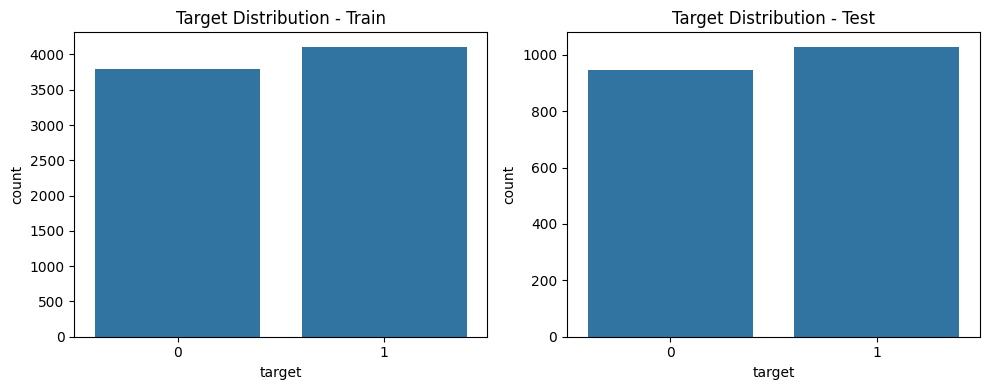

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(x=y_train, ax=axs[0])
axs[0].set_title('Target Distribution - Train')

sns.countplot(x=y_test, ax=axs[1])
axs[1].set_title('Target Distribution - Test')
plt.tight_layout()
plt.show()



In [ ]:
from collections import Counter

train_counter = Counter(y_train)
test_counter = Counter(y_test)

print("Train Distribution:", {k: f"{v/len(y_train):.2%}" for k, v in train_counter.items()})
print("Test Distribution:", {k: f"{v/len(y_test):.2%}" for k, v in test_counter.items()})


Train Distribution: {1: '52.02%', 0: '47.98%'}
Test Distribution: {1: '52.05%', 0: '47.95%'}


vì bad nó chiếm tới 50% -> ko cần sampling để cân bằng

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

model = LogisticRegression(solver='liblinear')
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print("ROC AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))


ROC AUC: 0.8165633641357717
              precision    recall  f1-score   support

           0       0.76      0.69      0.72       947
           1       0.74      0.80      0.77      1028

    accuracy                           0.75      1975
   macro avg       0.75      0.75      0.75      1975
weighted avg       0.75      0.75      0.75      1975



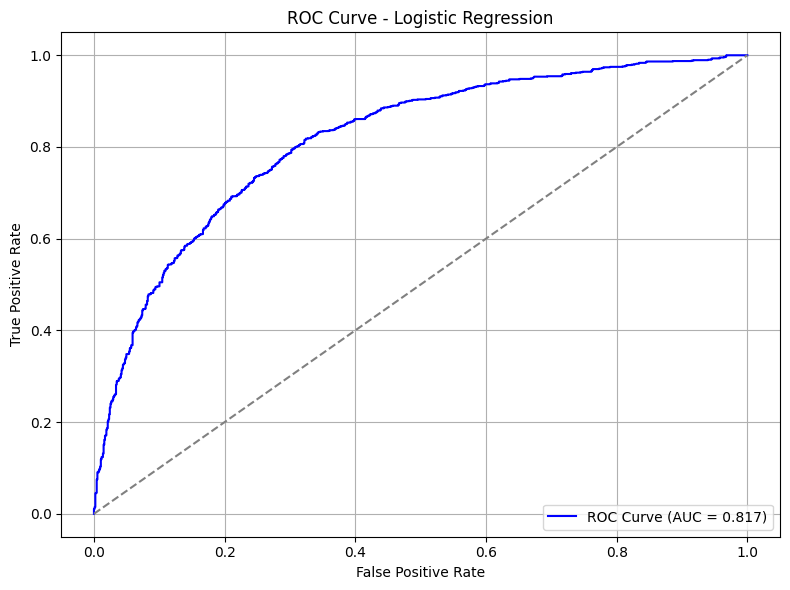

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Tính FPR, TPR
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label='ROC Curve (AUC = %0.3f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()



<ipython-input-34-927ad5c181af>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Baseline', 'Logistic Regression'], y=[baseline_acc, accuracy], palette='Set2')


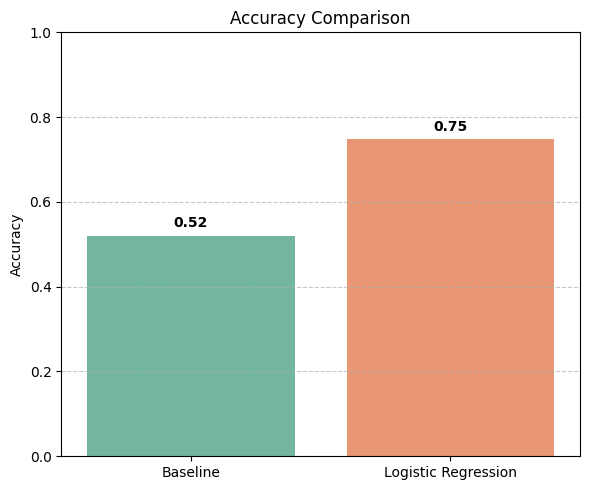

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

# Tính baseline accuracy (ví dụ với chiến lược "predict most frequent")
baseline_model = DummyClassifier(strategy='most_frequent')
baseline_model.fit(X_train_scaled, y_train)
baseline_acc = baseline_model.score(X_test_scaled, y_test)

# Tính accuracy của Logistic Regression
accuracy = accuracy_score(y_test, y_pred)

# Plot so sánh
plt.figure(figsize=(6, 5))
sns.barplot(x=['Baseline', 'Logistic Regression'], y=[baseline_acc, accuracy], palette='Set2')
plt.title('Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
for i, acc in enumerate([baseline_acc, accuracy]):
    plt.text(i, acc + 0.02, f'{acc:.2f}', ha='center', fontweight='bold')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
